In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the mathematically optimized data
df = pd.read_csv('cleaned_data_week1.csv')

In [13]:
df['festival'].fillna("None", inplace=True)
df['is_festival'] = np.where(df['festival'] == "None", 0, 1)
df

C:\Users\raiti\AppData\Local\Temp\ipykernel_6744\3343761263.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['festival'].fillna("None", inplace=True)


,accident_id,city,state,latitude,longitude,hour,lanes,traffic_signal,visibility,temperature,...,weather_fog,weather_rain,road_type_rural,road_type_urban,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,0,Pune,Maharashtra,18.680827,73.930388,5,3,1,0,32,...,True,False,False,False,False,False,True,False,False,False
1,1,Mumbai,Maharashtra,18.817732,72.790846,4,4,0,2,34,...,False,False,False,True,False,False,True,False,False,False
2,2,Mumbai,Maharashtra,19.096889,72.819424,13,3,0,0,21,...,True,False,False,True,False,False,False,False,False,True
3,3,Chandigarh,Punjab,30.787805,76.847507,11,1,1,0,30,...,True,False,False,True,False,False,True,False,False,False
4,4,Chennai,Tamil Nadu,12.965155,80.283313,16,3,1,2,24,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,Bangalore,Karnataka,13.092276,77.599571,3,1,1,2,31,...,False,False,False,True,False,False,False,True,False,False
19996,19996,Chennai,Tamil Nadu,13.172928,80.157062,1,1,1,2,20,...,False,False,False,True,False,True,False,False,False,False
19997,19997,Chennai,Tamil Nadu,12.997170,80.150724,15,3,0,2,22,...,False,False,True,False,False,True,False,False,False,False
19998,19998,Kolkata,West Bengal,22.454882,88.322213,4,3,1,2,33,...,False,False,False,False,False,False,True,False,False,False


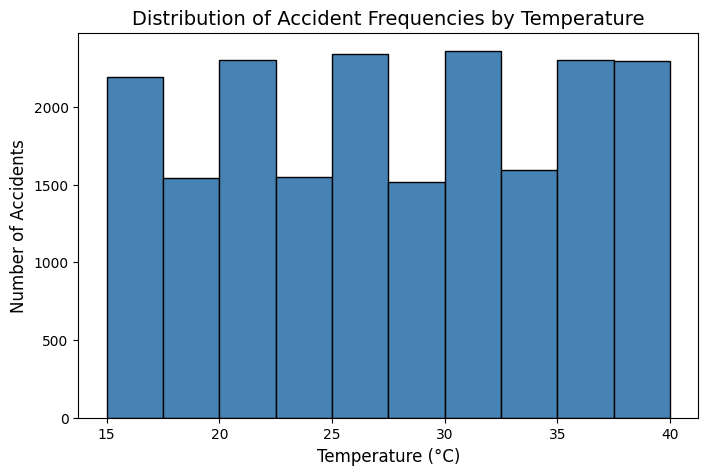

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(df['temperature'], bins=10, edgecolor='black', color='steelblue')
plt.title('Distribution of Accident Frequencies by Temperature', fontsize=14)
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.show()

### Interpretation

Accidents are distributed across the full temperature range of 15–40°C, with the largest concentrations appearing in several alternating temperature bands rather than at one clear extreme. This suggests that temperature alone is not a strong explanation for accident frequency in this dataset; traffic conditions, visibility, road type, and driver behavior should be examined alongside it before attributing a pattern to weather.

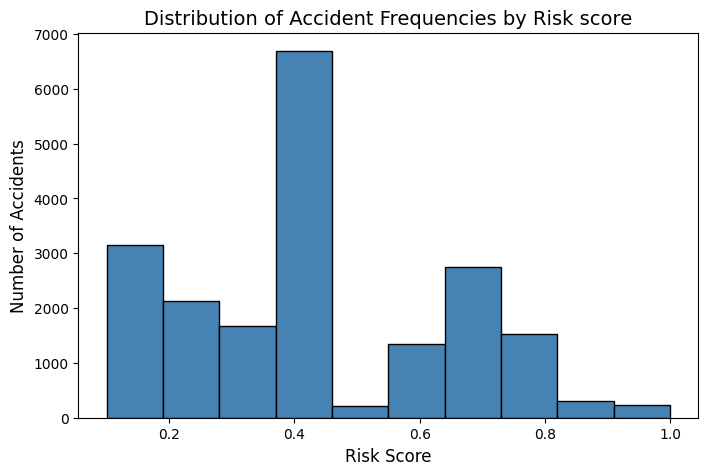

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df['risk_score'], bins=10, edgecolor='black', color='steelblue')
plt.title('Distribution of Accident Frequencies by Risk score', fontsize=14)
plt.xlabel('Risk Score', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.show()

### Interpretation

The risk scores are concentrated in the lower-to-middle range, especially around 0.37–0.46, with fewer observations at the highest scores. This indicates that most recorded accidents were assigned moderate risk rather than extreme risk; the distribution should be read as the dataset's risk-profile mix, not as evidence that high-risk conditions are uncommon in the real world.

C:\Users\raiti\AppData\Local\Temp\ipykernel_6744\4183262276.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='severity_label', y='temperature', data=df_plot,


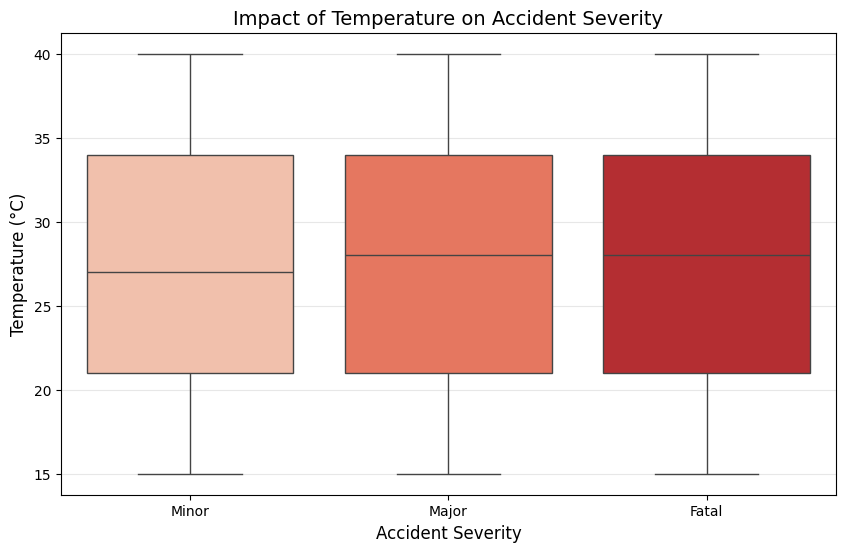

In [15]:
plt.figure(figsize=(10, 6))

# Map the numerical encoding back to text temporarily just for a readable chart
severity_labels = {0: 'Minor', 1: 'Major', 2: 'Fatal'}
df_plot = df.copy()
df_plot['severity_label'] = df_plot['accident_severity'].map(severity_labels)

# Use a color palette that implies danger/heat
sns.boxplot(x='severity_label', y='temperature', data=df_plot, 
            order=['Minor', 'Major', 'Fatal'], palette='Reds')

plt.title('Impact of Temperature on Accident Severity', fontsize=14)
plt.xlabel('Accident Severity', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

### Interpretation

The three severity groups have very similar temperature distributions: their medians are approximately 27–28°C and their ranges span the same 15–40°C interval. Temperature therefore does not visibly separate minor, major, and fatal accidents here; the small upward shift for major and fatal cases is weak and should not be treated as a causal effect without controlling for other factors.

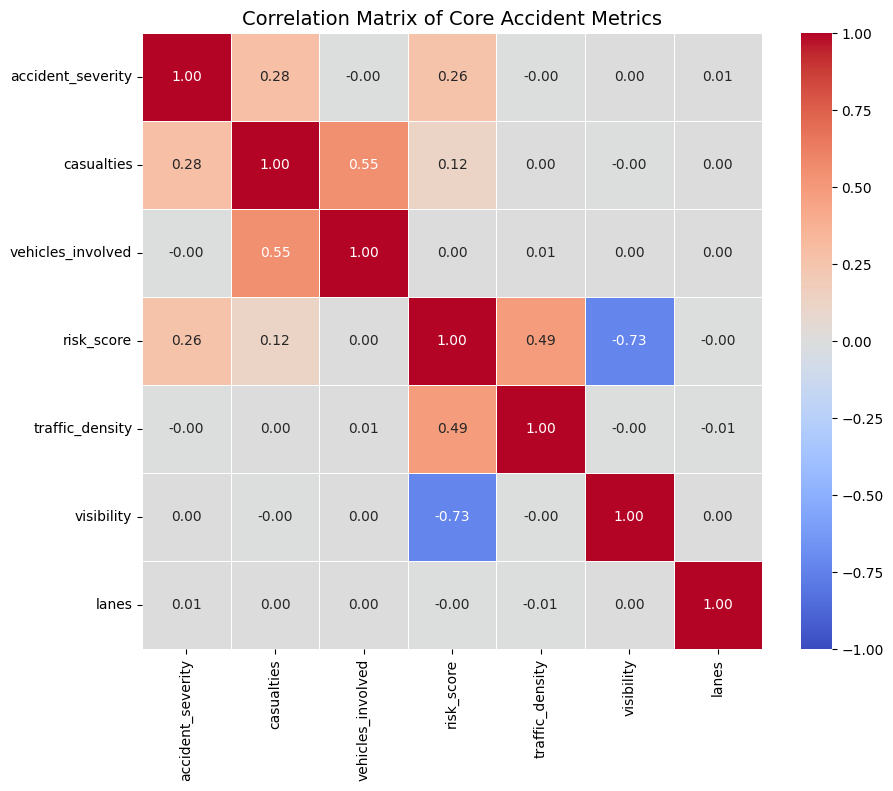

In [16]:
core_features = ['accident_severity', 'casualties', 'vehicles_involved', 
                 'risk_score', 'traffic_density', 'visibility', 'lanes']

plt.figure(figsize=(10, 8))

# Calculate the Pearson correlation matrix
corr_matrix = df[core_features].corr()

# Plot using a divergent color map (coolwarm) so negatives are blue and positives are red
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
            linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Matrix of Core Accident Metrics', fontsize=14)
plt.show()

### Interpretation

Risk score has the clearest relationships in this matrix: it rises with traffic density (about $r=0.49$) and falls as the encoded visibility value increases (about $r=-0.73$). Accident severity is moderately related to casualties ($r=0.28$) and risk score ($r=0.26$), while lanes and vehicles involved show almost no direct relationship with severity. Correlation identifies associations, not causes, and the meaning of the visibility coefficient depends on how its numeric categories were encoded.

C:\Users\raiti\AppData\Local\Temp\ipykernel_6744\3674278500.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='risk_score', y='city', data=city_risk, palette='Reds_r')


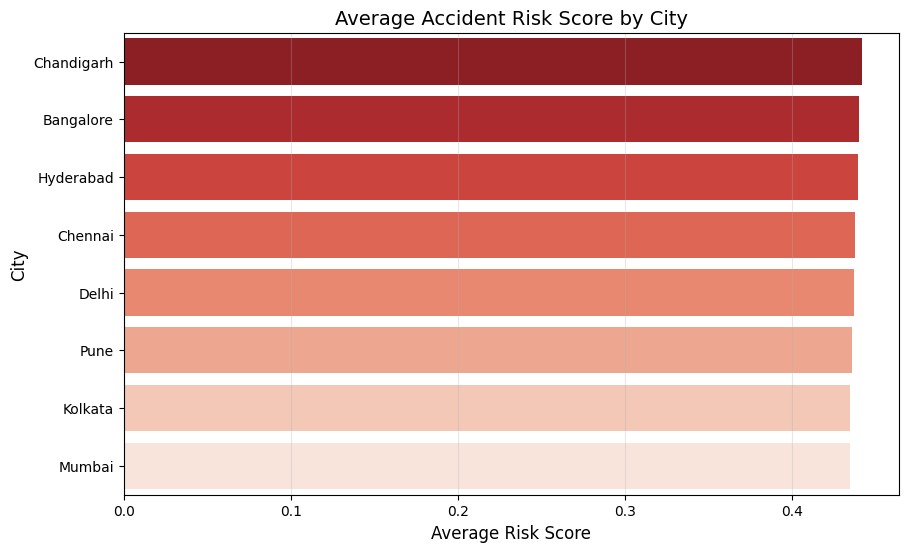

In [20]:
plt.figure(figsize=(10, 6))

# 1. The Aggregation: Group by city and calculate the average risk score
city_risk = df.groupby('city')['risk_score'].mean().sort_values(ascending=False).reset_index()

# 2. The Visualization: Horizontal bar chart for readable city names
sns.barplot(x='risk_score', y='city', data=city_risk, palette='Reds_r')

plt.title('Average Accident Risk Score by City', fontsize=14)
plt.xlabel('Average Risk Score', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.show()

### Interpretation

Average risk scores are tightly grouped across cities, ranging from about 0.434 in Mumbai to 0.442 in Chandigarh. Chandigarh ranks highest, but the spread is only about 0.007, so city is not a strong differentiator of average risk in this sample; local differences may be smaller than the variation caused by traffic, visibility, or the mix of accidents recorded.

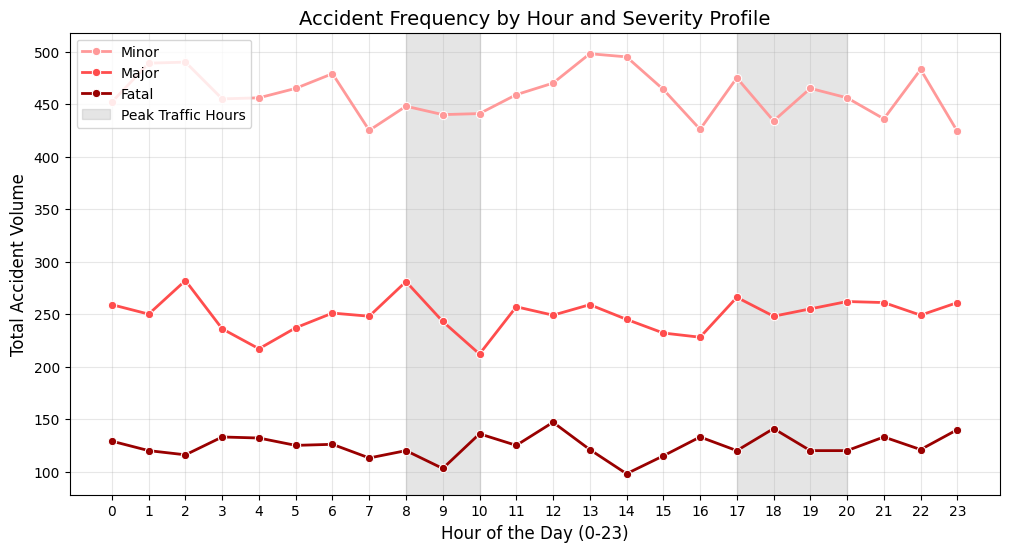

In [21]:
plt.figure(figsize=(12, 6))

# 1. Group the data by hour and severity to get the total counts
hourly_data = df.groupby(['hour', 'accident_severity']).size().reset_index(name='accident_count')

# Map the numerical severity back to text just for a readable legend
severity_map = {0: 'Minor', 1: 'Major', 2: 'Fatal'}
hourly_data['Severity'] = hourly_data['accident_severity'].map(severity_map)

# 2. Plot the line chart
sns.lineplot(data=hourly_data, x='hour', y='accident_count', hue='Severity', 
             palette=['#ff9999', '#ff4d4d', '#990000'], marker='o', linewidth=2)

# 3. Add visual shading for peak hours (Assuming 8-10 AM and 5-8 PM based on standard metrics)
plt.axvspan(8, 10, color='gray', alpha=0.2, label='Peak Traffic Hours')
plt.axvspan(17, 20, color='gray', alpha=0.2)

plt.title('Accident Frequency by Hour and Severity Profile', fontsize=14)
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Total Accident Volume', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)

# Fix legend duplicates from the shading
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left')

plt.show()

### Interpretation

Accident volume is fairly even across the 24 hours, and the shaded commute windows do not produce a dramatic spike in this sample. Fatal accidents remain the least frequent category at every hour, while minor accidents consistently form the largest share. Because the chart aggregates all days together, it cannot test whether a particular hour is more dangerous on weekends; that question would require grouping by both hour and day of week, then cross-referencing cause indicators such as drunk driving or overspeeding.

C:\Users\raiti\AppData\Local\Temp\ipykernel_6744\3791521464.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total Accidents', y='Cause', data=cause_df, palette='viridis')


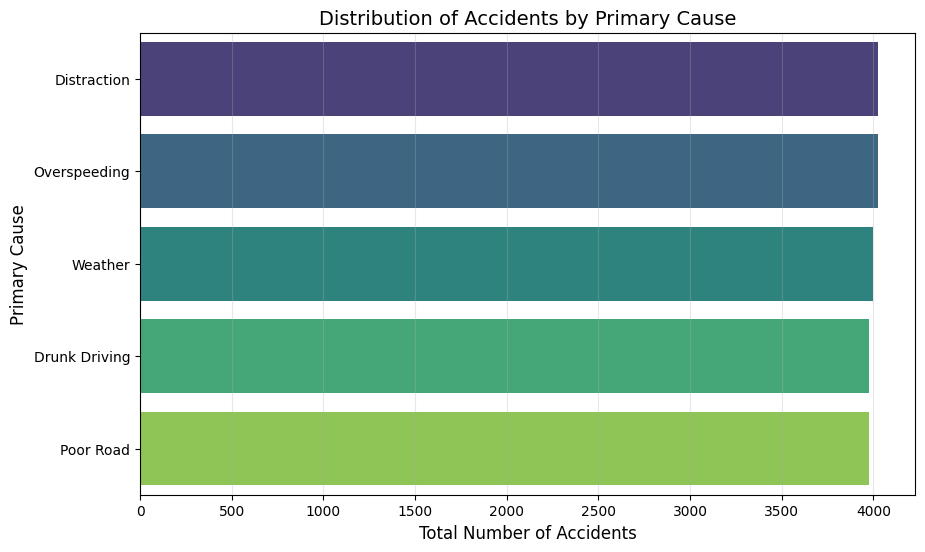

In [22]:
# Since 'cause' was One-Hot Encoded, we sum the boolean columns to get the totals
# We also calculate the dropped 'distraction' base category by subtracting the others from the total rows
cause_counts = {
    'Drunk Driving': df['cause_drunk driving'].sum(),
    'Overspeeding': df['cause_overspeeding'].sum(),
    'Poor Road': df['cause_poor road'].sum(),
    'Weather': df['cause_weather'].sum()
}

# The dropped 'distraction' category is the total rows minus the sum of the other causes
cause_counts['Distraction'] = len(df) - sum(cause_counts.values())

# Convert to a dataframe for easy plotting
cause_df = pd.DataFrame(list(cause_counts.items()), columns=['Cause', 'Total Accidents']).sort_values(by='Total Accidents', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Total Accidents', y='Cause', data=cause_df, palette='viridis')

plt.title('Distribution of Accidents by Primary Cause', fontsize=14)
plt.xlabel('Total Number of Accidents', fontsize=12)
plt.ylabel('Primary Cause', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.show()

### Interpretation

The four explicitly encoded causes occur at nearly equal levels: overspeeding is highest at 4,025 cases, followed by weather at 3,997, drunk driving at 3,978, and poor road conditions at 3,974. The inferred distraction category makes up the remaining accidents, so it should be interpreted cautiously because it is calculated as a residual rather than read from its own indicator column. The near balance means no single listed cause dominates the overall sample; useful differences may appear only after breaking causes down by severity, hour, city, or weather condition.

C:\Users\raiti\AppData\Local\Temp\ipykernel_6744\1118030319.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Severity_Label', data=plot_data, order=['Minor', 'Major', 'Fatal'],
C:\Users\raiti\AppData\Local\Temp\ipykernel_6744\1118030319.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='lanes', data=plot_data, palette='Blues', ax=axes[1])


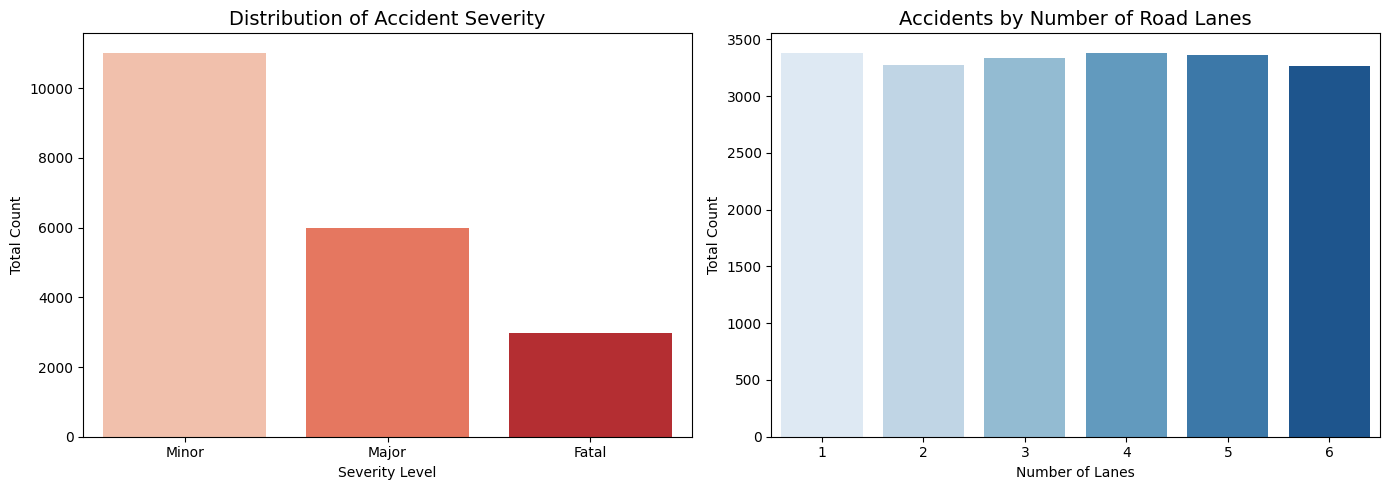

In [24]:
# Set up a side-by-side figure (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Accident Severity Countplot
# Temporarily map the 0,1,2 integers back to strings for a readable chart
severity_map = {0: 'Minor', 1: 'Major', 2: 'Fatal'}
plot_data = df.copy()
plot_data['Severity_Label'] = plot_data['accident_severity'].map(severity_map)

sns.countplot(x='Severity_Label', data=plot_data, order=['Minor', 'Major', 'Fatal'], 
              palette='Reds', ax=axes[0])
axes[0].set_title('Distribution of Accident Severity', fontsize=14)
axes[0].set_xlabel('Severity Level')
axes[0].set_ylabel('Total Count')

# 2. Lanes Countplot
sns.countplot(x='lanes', data=plot_data, palette='Blues', ax=axes[1])
axes[1].set_title('Accidents by Number of Road Lanes', fontsize=14)
axes[1].set_xlabel('Number of Lanes')
axes[1].set_ylabel('Total Count')

plt.tight_layout()
plt.show()

### Interpretation

Minor accidents are the most common outcome (11,025), followed by major accidents (5,988) and fatal accidents (2,987), showing a clear severity imbalance in the sample. The lane chart is nearly uniform from one to six lanes, with roughly 3,270–3,383 accidents per lane count, so lane count is not overrepresented in any single category. Together, these plots suggest that severity differences are more informative than lane frequency, but they do not show whether lane count changes the probability of a fatal outcome; a severity-by-lanes comparison would be needed for that.